#Import libraries/data

In [1]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
!pip install -q -U keras-tuner
!pip install -q imbalanced-learn
from keras_tuner import HyperParameters

# feel free to import other libraries as needed
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE
import warnings
import geopandas as gpd
from datetime import timedelta
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Split Dataset

In [3]:
# Use data split provided by Nichole during data preprocessing
# Load x data
X_train = pd.read_csv("/content/drive/MyDrive/DATASCI207/CalFire/X_train.csv")
X_val = pd.read_csv("/content/drive/MyDrive/DATASCI207/CalFire/X_val.csv")
X_test = pd.read_csv("/content/drive/MyDrive/DATASCI207/CalFire/X_test.csv")

# Load y data
y_train = pd.read_csv("/content/drive/MyDrive/DATASCI207/CalFire/y_train.csv")
y_val = pd.read_csv("/content/drive/MyDrive/DATASCI207/CalFire/y_val.csv")
y_test = pd.read_csv("/content/drive/MyDrive/DATASCI207/CalFire/y_test.csv")

print(f"Loaded datasets with shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Loaded datasets with shapes:
X_train: (12426, 345), y_train: (12426, 3)
X_val: (4142, 345), y_val: (4142, 3)
X_test: (4142, 345), y_test: (4142, 3)


In [4]:
# Count unique values in target variables
print("Unique values in y_train['y_3']:", y_train['y_3'].unique())
print("Unique values in y_train['y_7']:", y_train['y_7'].unique())
print("Unique values in y_train['y_14']:", y_train['y_14'].unique())

Unique values in y_train['y_3']: [0 1 2 3 4 5 6 7]
Unique values in y_train['y_7']: [0 1 2 3 4 5 6 7]
Unique values in y_train['y_14']: [0 1 2 3 5 7 4 6]


In [5]:
# Distribution of target variables
print("\nDistribution of y_3:")
print(y_train['y_3'].value_counts().sort_index())
print("\nDistribution of y_7:")
print(y_train['y_7'].value_counts().sort_index())
print("\nDistribution of y_14:")
print(y_train['y_14'].value_counts().sort_index())



Distribution of y_3:
y_3
0    5196
1    1982
2    2133
3     566
4    1108
5     337
6     890
7     214
Name: count, dtype: int64

Distribution of y_7:
y_7
0    4120
1    2363
2    2403
3     685
4    1304
5     395
6     903
7     253
Name: count, dtype: int64

Distribution of y_14:
y_14
0    3420
1    2696
2    2446
3     782
4    1437
5     429
6     920
7     296
Name: count, dtype: int64


In [14]:
target_col = 'y_3'
y_train_target = y_train[target_col].values
y_val_target = y_val[target_col].values
y_test_target = y_test[target_col].values

In [15]:
# Handle features for modeling
# Extract DATE column and convert to datetime for potential time series analysis
X_train_dates = pd.to_datetime(X_train['DATE']) if 'DATE' in X_train.columns else None
X_val_dates = pd.to_datetime(X_val['DATE']) if 'DATE' in X_val.columns else None
X_test_dates = pd.to_datetime(X_test['DATE']) if 'DATE' in X_test.columns else None

# Drop DATE column for modeling
X_train_model = X_train.drop('DATE', axis=1) if 'DATE' in X_train.columns else X_train.copy()
X_val_model = X_val.drop('DATE', axis=1) if 'DATE' in X_val.columns else X_val.copy()
X_test_model = X_test.drop('DATE', axis=1) if 'DATE' in X_test.columns else X_test.copy()

In [16]:
# Feature Engineering: Create active_conus column
conus_columns = [col for col in X_train.columns if 'conus_code' in col]
print("Conus code columns:", conus_columns)

# Function to get active conus code
def get_active_conus(row, conus_columns):
    for col in conus_columns:
        if row[col]:
            return col.replace('conus_code_', '').replace('.0', '')
    return 'unknown'

X_train['active_conus'] = X_train.apply(lambda row: get_active_conus(row, conus_columns), axis=1)
X_val['active_conus'] = X_val.apply(lambda row: get_active_conus(row, conus_columns), axis=1)
X_test['active_conus'] = X_test.apply(lambda row: get_active_conus(row, conus_columns), axis=1)

# Distribution of active_conus values
print("\nDistribution of active_conus values in training set:")
print(X_train['active_conus'].value_counts())

Conus code columns: ['conus_code_401.0', 'conus_code_402.0', 'conus_code_403.0', 'conus_code_404.0', 'conus_code_405.0', 'conus_code_406.0', 'conus_code_407.0', 'conus_code_not_used']

Distribution of active_conus values in training set:
active_conus
not_used    6886
405         1562
406         1417
402          889
401          848
407          382
404          264
403          178
Name: count, dtype: int64


In [17]:
# Create combined dataset for EDA
X_train_with_targets = X_train.copy()
X_train_with_targets['y_3'] = y_train['y_3'].values
X_train_with_targets['y_7'] = y_train['y_7'].values
X_train_with_targets['y_14'] = y_train['y_14'].values

# Look at fire distribution by conus region
fire_by_conus = X_train_with_targets.groupby('active_conus').agg({
    'y_3': 'mean',
    'y_7': 'mean',
    'y_14': 'mean'
}).reset_index()

print("\nAverage fire counts by conus region:")
print(fire_by_conus)


Average fire counts by conus region:
  active_conus       y_3       y_7      y_14
0          401  4.255896  3.675708  3.321934
1          402  3.533183  3.289089  3.145107
2          403  4.449438  3.500000  3.151685
3          404  3.556818  3.079545  2.840909
4          405  2.383483  2.471831  2.458387
5          406  1.733945  1.937897  2.073394
6          407  2.835079  2.638743  2.599476
7     not_used  0.748911  1.236131  1.557363


<Figure size 1200x600 with 0 Axes>

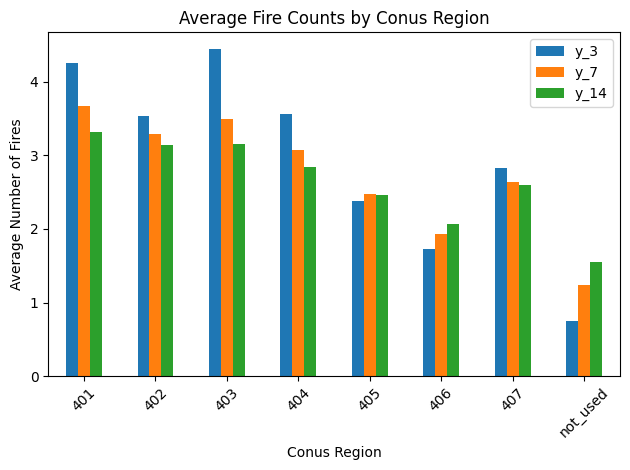

In [18]:
# Visualize fire counts by conus
plt.figure(figsize=(12, 6))
fire_by_conus.set_index('active_conus')[['y_3', 'y_7', 'y_14']].plot(kind='bar')
plt.title('Average Fire Counts by Conus Region')
plt.ylabel('Average Number of Fires')
plt.xlabel('Conus Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Standardize the data
scaler = StandardScaler()

# Convert columns with 'not_used' to numeric
for column in X_train_model.select_dtypes(include=['object']).columns:
    X_train_model[column] = pd.to_numeric(X_train_model[column], errors='coerce').fillna(0)
    X_val_model[column] = pd.to_numeric(X_val_model[column], errors='coerce').fillna(0)
    X_test_model[column] = pd.to_numeric(X_test_model[column], errors='coerce').fillna(0)

X_train_scaled = scaler.fit_transform(X_train_model)
X_val_scaled = scaler.transform(X_val_model)
X_test_scaled = scaler.transform(X_test_model)

# PCA (Principle Component Analysis)

In [21]:
pca = PCA(n_components=10, random_state=42)
# Fit PCA
pca.fit(X_train_scaled)

PCA(n_components=10, random_state=42)

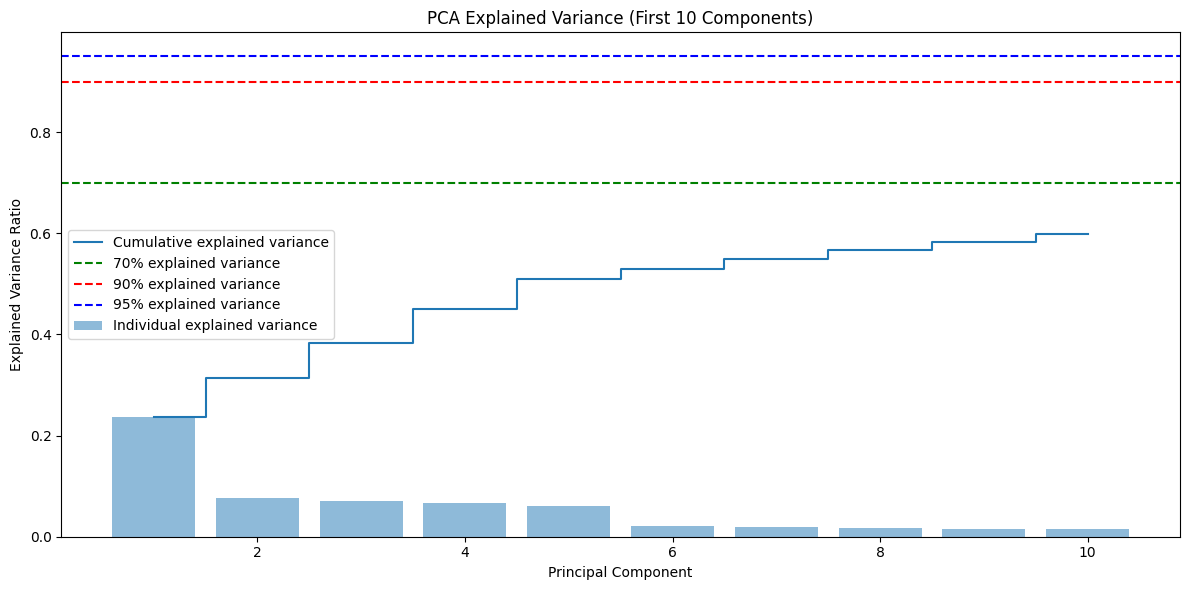

In [22]:
# Plot explained variance
plt.figure(figsize=(12, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10], alpha=0.5, align='center',
        label='Individual explained variance')
plt.step(range(1, 11), np.cumsum(pca.explained_variance_ratio_[:10]), where='mid',
         label='Cumulative explained variance')
plt.axhline(y=0.7, color='g', linestyle='--', label='70% explained variance')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% explained variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (First 10 Components)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [23]:
# Transform the data
X_train_pca = pca.transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Analyze component loadings
feature_names = X_train_model.columns
loadings = pca.components_

# Create a DataFrame for component loadings
loadings_df = pd.DataFrame()
for i in range(2):  # First two components
    loadings_df[f'PC{i+1}'] = [abs(loadings[i, j]) for j in range(len(feature_names))]
loadings_df['Feature'] = feature_names
loadings_df = loadings_df.set_index('Feature')

# Show the top contributing features for first two components
print("\nTop 10 features for first two principal components:")
for i in range(2):
    pc_loadings = loadings_df[f'PC{i+1}'].sort_values(ascending=False)
    print(f"Principal Component {i+1}:")
    print(pc_loadings.head(10))
    print()


Top 10 features for first two principal components:
Principal Component 1:
Feature
RH2M_0404_LAG_3    0.089749
RH2M_0404          0.089409
RH2M_0403_LAG_3    0.089225
RH2M_0403          0.088978
RH2M_0402_LAG_3    0.088937
RH2M_0402          0.088690
RH2M_0404_LAG_7    0.088090
RH2M_0403_LAG_7    0.087885
RH2M_0401_LAG_3    0.087590
RH2M_0401          0.087390
Name: PC1, dtype: float64

Principal Component 2:
Feature
T2M_0404               0.104043
QV2M_0403_LAG_14       0.103610
T2M_MAX_0403           0.102648
T2M_MAX_0404           0.102566
T2M_MAX_0403_LAG_14    0.102287
T2M_MIN_0404           0.102100
T2M_0404_LAG_14        0.101803
T2M_MAX_0407_LAG_14    0.101676
T2M_MAX_0404_LAG_14    0.100653
T2M_0407_LAG_14        0.100313
Name: PC2, dtype: float64



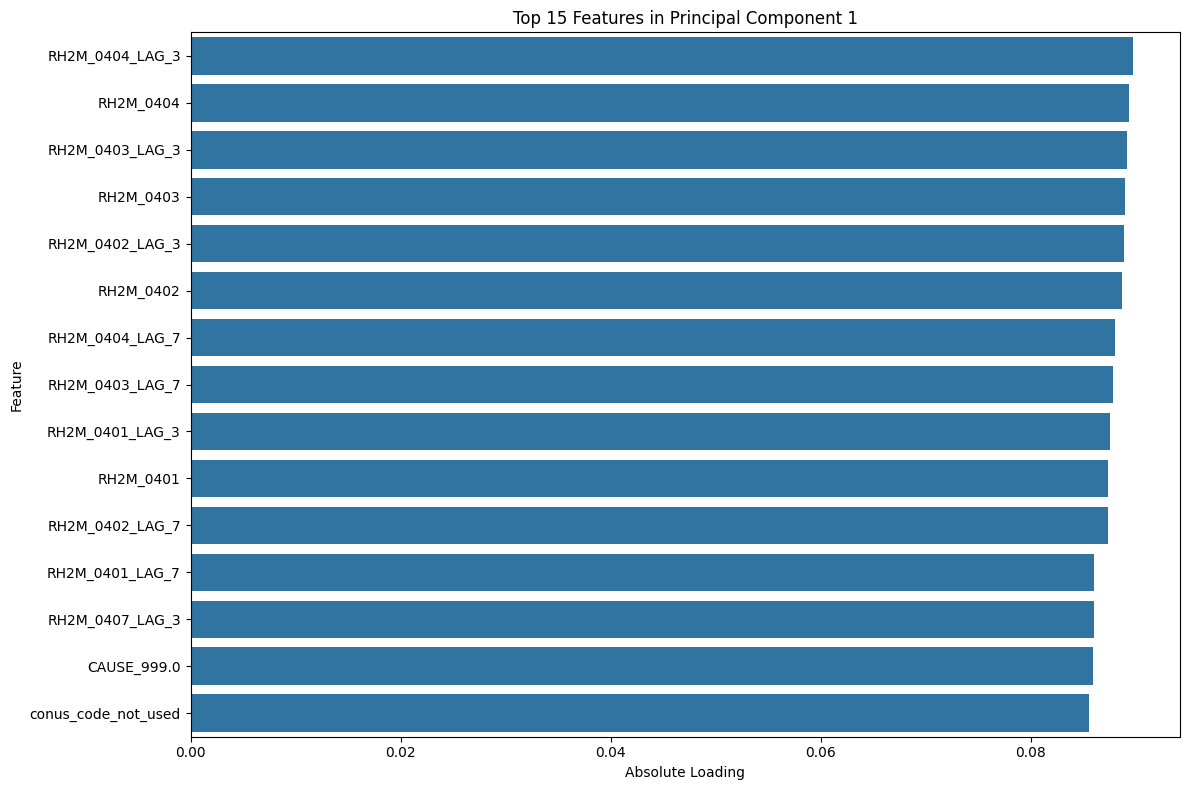

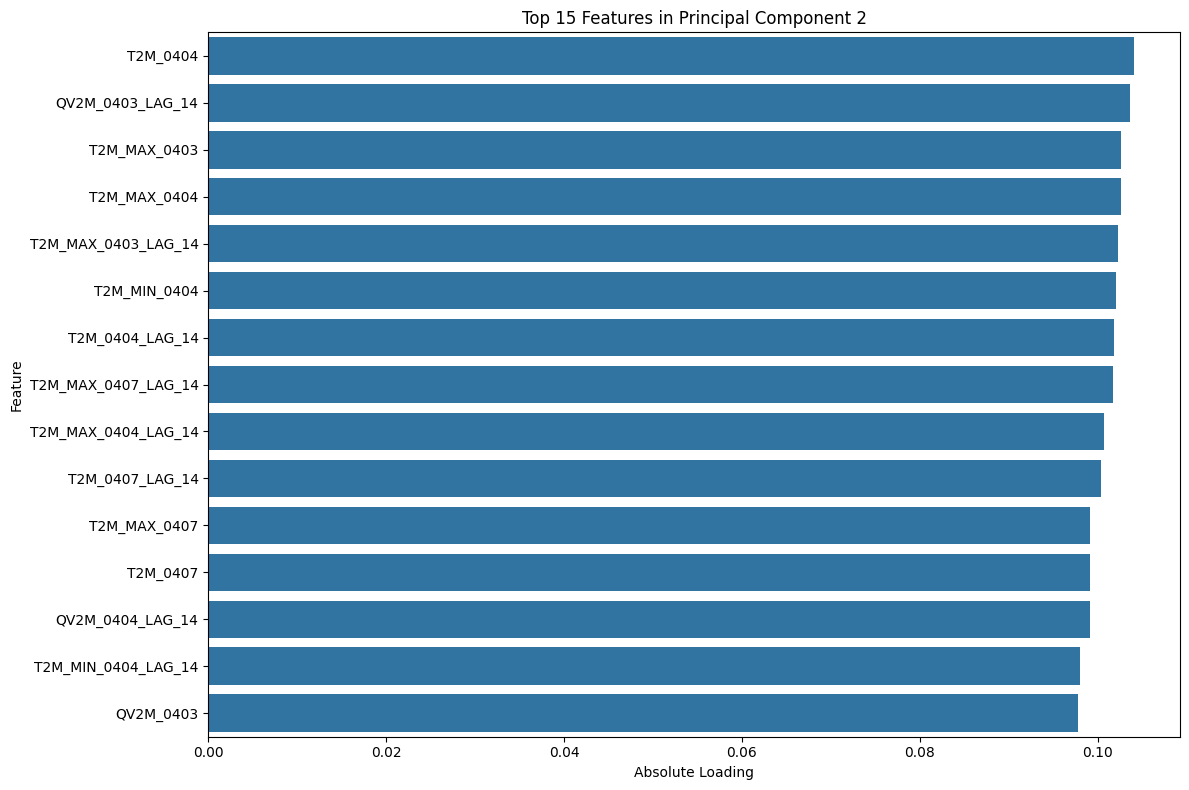

In [24]:
# Visualize top features in first principal component
plt.figure(figsize=(12, 8))
pc1_top_features = loadings_df['PC1'].sort_values(ascending=False).head(15)
sns.barplot(x=pc1_top_features.values, y=pc1_top_features.index)
plt.title('Top 15 Features in Principal Component 1')
plt.xlabel('Absolute Loading')
plt.tight_layout()
plt.show()

# Visualize top features in second principal component
plt.figure(figsize=(12, 8))
pc2_top_features = loadings_df['PC2'].sort_values(ascending=False).head(15)
sns.barplot(x=pc2_top_features.values, y=pc2_top_features.index)
plt.title('Top 15 Features in Principal Component 2')
plt.xlabel('Absolute Loading')
plt.tight_layout()
plt.show()

# Random Forest Classification

### Baseline model

Validation accuracy for y_3: 0.5703
Test Accuracy for y_3: 0.5345
Test Precision for y_3: 0.4634
Test Recall for y_3: 0.4187
Test F1 Score for y_3: 0.4332


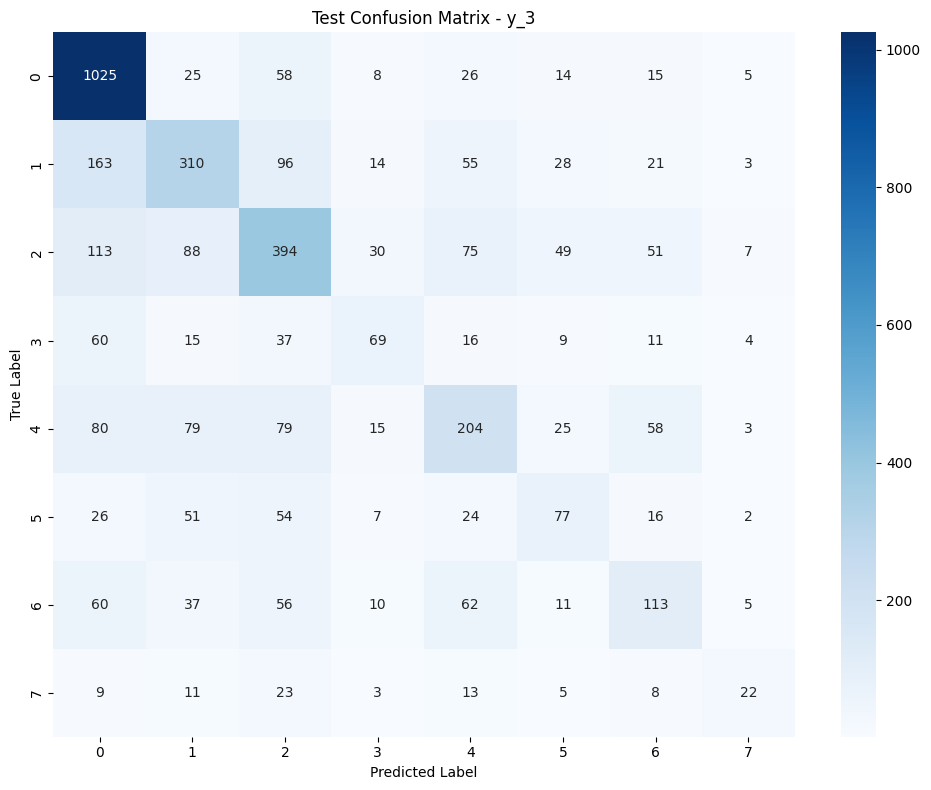

Validation accuracy for y_7: 0.4049
Test Accuracy for y_7: 0.4034
Test Precision for y_7: 0.3212
Test Recall for y_7: 0.2841
Test F1 Score for y_7: 0.2847


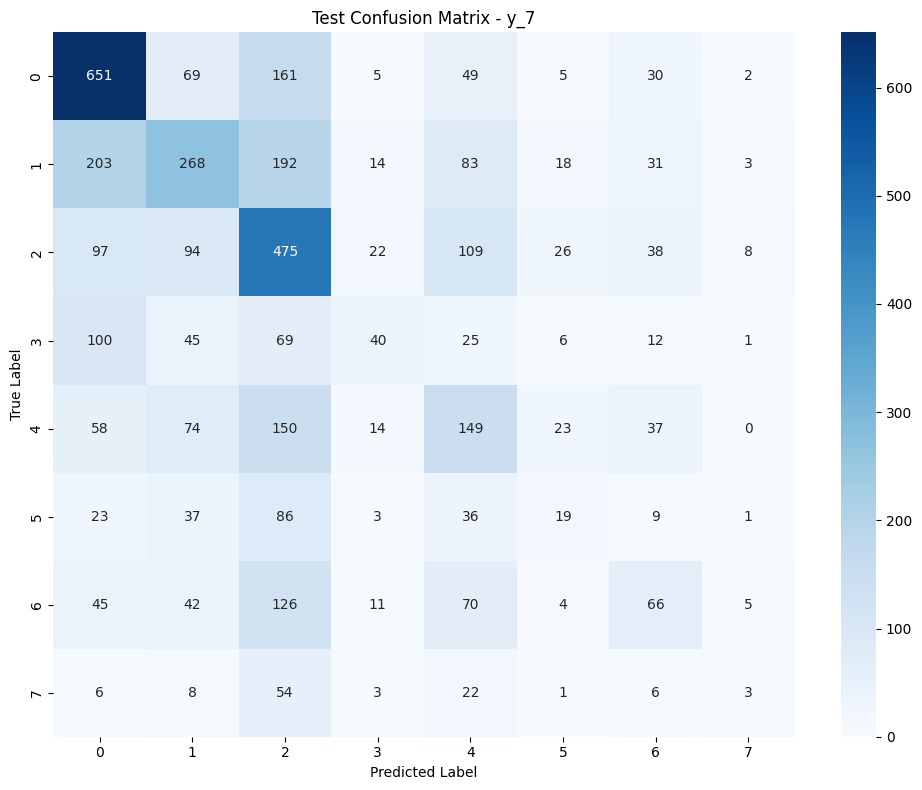

Validation accuracy for y_14: 0.3351
Test Accuracy for y_14: 0.3387
Test Precision for y_14: 0.2405
Test Recall for y_14: 0.2270
Test F1 Score for y_14: 0.2153


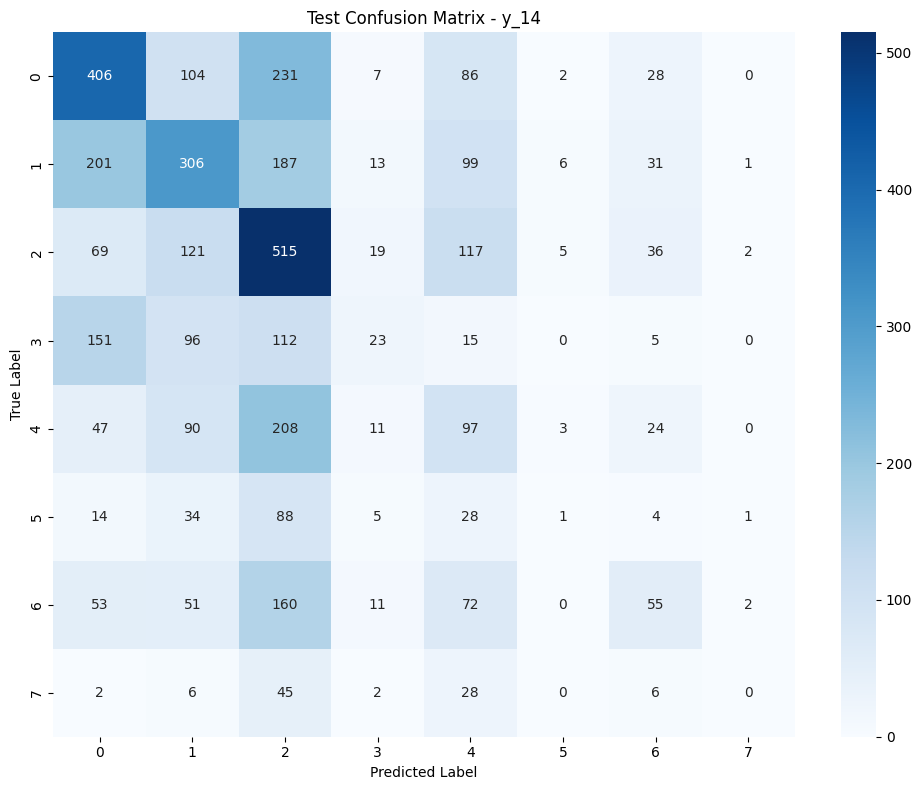

In [25]:
def train_baseline_rf(X_train, y_train, X_val, y_val):
    """
    Train a baseline Random Forest model without PCA

    Parameters:
    -----------
    X_train : Feature matrix for training
    y_train : Target vector for training
    X_val : Feature matrix for validation
    y_val : Target vector for validation

    Returns:
    --------
    dict : Dictionary containing model, predictions, and evaluation metrics
    """
    # Initialize model
    rf = RandomForestClassifier(
        n_estimators=100,  # Number of trees
        max_depth=20,      # Maximum depth of trees
        random_state=42,
        class_weight='balanced',
        n_jobs=-1          # Use all cores
    )

    # Train model
    rf.fit(X_train, y_train)

    # Make predictions
    y_val_pred = rf.predict(X_val)

    # Evaluate model
    accuracy = accuracy_score(y_val, y_val_pred)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    class_report = classification_report(y_val, y_val_pred, output_dict=True)

    # Get feature importances
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]

    return {
        'model': rf,
        'predictions': y_val_pred,
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'feature_importances': {X_train.columns[i]: importances[i] for i in indices}
    }

# Train models for each target
targets = ['y_3', 'y_7', 'y_14']
baseline_results = {}
test_results = {}

for target in targets:
    baseline_results[target] = train_baseline_rf(
        X_train_model,
        y_train[target],
        X_val_model,
        y_val[target]
    )
    print(f"Validation accuracy for {target}: {baseline_results[target]['accuracy']:.4f}")

    # Evaluate on test set
    # Get the trained model from baseline_results
    model = baseline_results[target]['model']

    # Make predictions on test set
    y_test_pred = model.predict(X_test_model)

    # Calculate metrics
    test_accuracy = accuracy_score(y_test[target], y_test_pred)
    test_conf_matrix = confusion_matrix(y_test[target], y_test_pred)
    test_report = classification_report(y_test[target], y_test_pred, output_dict=True)

    # Extract precision, recall, and f1 (macro averages)
    test_precision = test_report['macro avg']['precision']
    test_recall = test_report['macro avg']['recall']
    test_f1 = test_report['macro avg']['f1-score']

    # Store test results
    test_results[target] = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'confusion_matrix': test_conf_matrix,
        'classification_report': test_report,
        'predictions': y_test_pred
    }

    # Display test metrics
    print(f"Test Accuracy for {target}: {test_accuracy:.4f}")
    print(f"Test Precision for {target}: {test_precision:.4f}")
    print(f"Test Recall for {target}: {test_recall:.4f}")
    print(f"Test F1 Score for {target}: {test_f1:.4f}")

    # Show confusion matrix for test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Test Confusion Matrix - {target}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


### PCA Modeling/Hyper-parameter tuning

Validation accuracy for y_3: 0.5212
Test Accuracy for y_3: 0.4983
Test Precision for y_3: 0.3886
Test Recall for y_3: 0.3262
Test F1 Score for y_3: 0.3229


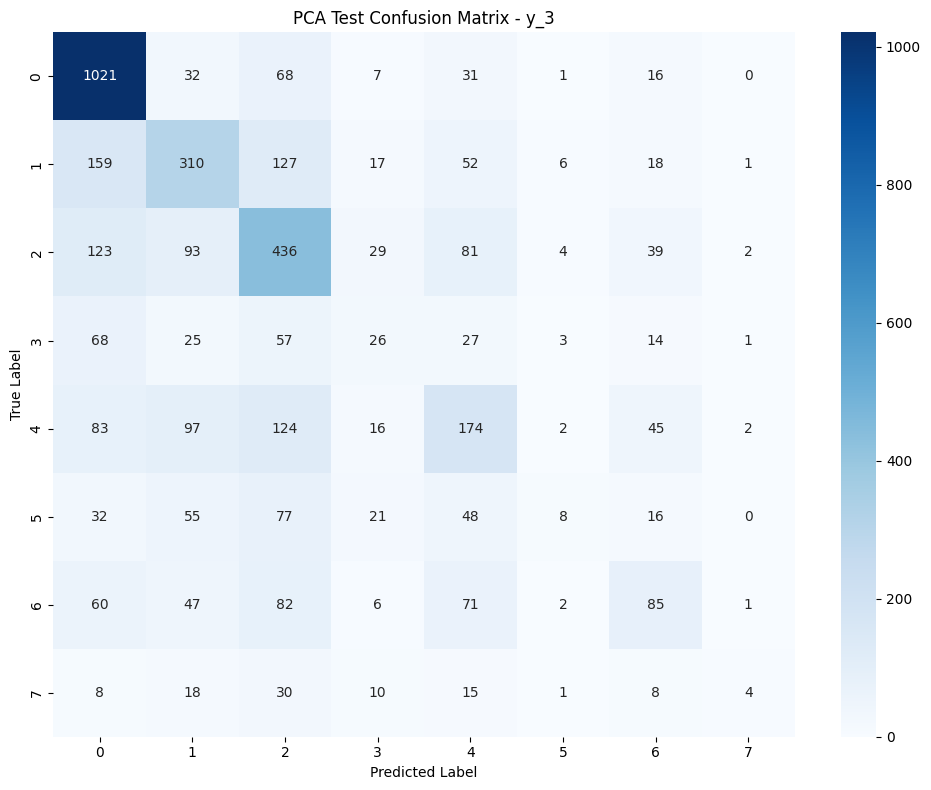

Validation accuracy for y_7: 0.3735
Test Accuracy for y_7: 0.3889
Test Precision for y_7: 0.2505
Test Recall for y_7: 0.2517
Test F1 Score for y_7: 0.2376


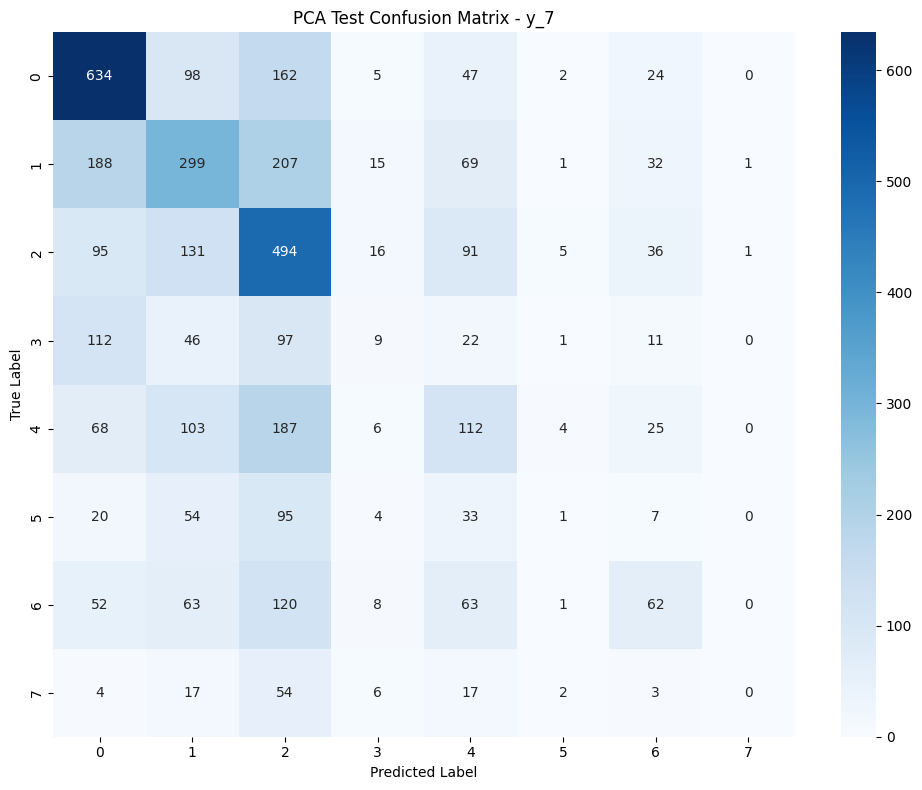

Validation accuracy for y_14: 0.3124
Test Accuracy for y_14: 0.3252
Test Precision for y_14: 0.2141
Test Recall for y_14: 0.2147
Test F1 Score for y_14: 0.2006


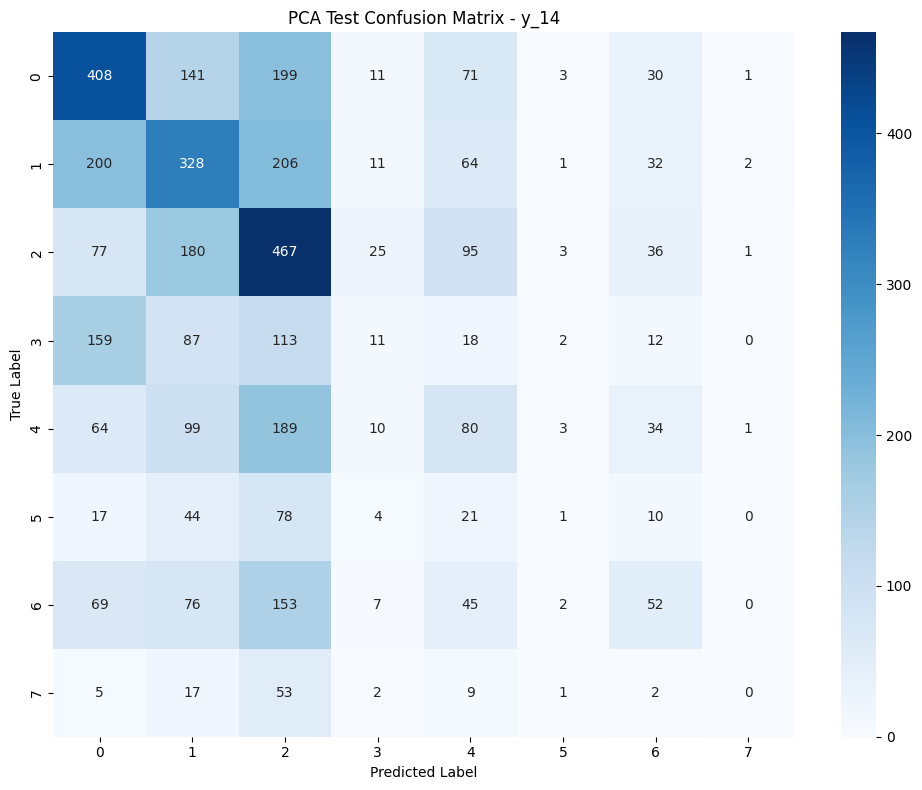

In [27]:
# PCA model
def train_pca_rf(X_train_pca, y_train, X_val_pca, y_val):
    """
    Train a Random Forest model with PCA-transformed features

    Parameters:
    -----------
    X_train_pca : PCA-transformed feature matrix for training
    y_train : Target vector for training
    X_val_pca : PCA-transformed feature matrix for validation
    y_val : Target vector for validation

    Returns:
    --------
    dict : Dictionary containing model, predictions, and evaluation metrics
    """
    # Initialize model
    rf = RandomForestClassifier(
        n_estimators = 300,  # Number of trees
        max_depth = 50,      # Maximum depth of trees
        random_state=42,
        min_samples_split = 2,
        min_samples_leaf = 1,
        max_features = 'sqrt',
        class_weight='balanced', #balanced for class imbalance
        n_jobs=-1
    )

    # Train model
    rf.fit(X_train_pca, y_train)

    # Make predictions
    y_val_pred = rf.predict(X_val_pca)

    # Evaluate model
    accuracy = accuracy_score(y_val, y_val_pred)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    class_report = classification_report(y_val, y_val_pred, output_dict=True)

    # Calculate ROC curve and AUC for binary classification
    # or for each class in multi-class
    roc_auc = None
    unique_classes = np.unique(y_train)

    if len(unique_classes) == 2:
        fpr, tpr, _ = roc_curve(y_val, rf.predict_proba(X_val_pca)[:, 1])
        roc_auc = auc(fpr, tpr)

    return {
        'model': rf,
        'predictions': y_val_pred,
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'roc_auc': roc_auc
    }

# Train PCA models for each target
pca_results = {}
test_results_pca = {}

for target in targets:
    pca_results[target] = train_pca_rf(
        X_train_pca,
        y_train[target],
        X_val_pca,
        y_val[target]
    )
    print(f"Validation accuracy for {target}: {pca_results[target]['accuracy']:.4f}")

    # Evaluate on test set
    # Get the trained model from pca_results
    model = pca_results[target]['model']

    # Make predictions on test set (using PCA-transformed test data)
    y_test_pred = model.predict(X_test_pca)

    # Calculate metrics
    test_accuracy = accuracy_score(y_test[target], y_test_pred)
    test_conf_matrix = confusion_matrix(y_test[target], y_test_pred)
    test_report = classification_report(y_test[target], y_test_pred, output_dict=True)

    # Extract precision, recall, and f1 (macro averages)
    test_precision = test_report['macro avg']['precision']
    test_recall = test_report['macro avg']['recall']
    test_f1 = test_report['macro avg']['f1-score']

    # Store test results
    test_results_pca[target] = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'confusion_matrix': test_conf_matrix,
        'classification_report': test_report,
        'predictions': y_test_pred
    }

    # Display test metrics
    print(f"Test Accuracy for {target}: {test_accuracy:.4f}")
    print(f"Test Precision for {target}: {test_precision:.4f}")
    print(f"Test Recall for {target}: {test_recall:.4f}")
    print(f"Test F1 Score for {target}: {test_f1:.4f}")

    # Show confusion matrix for test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'PCA Test Confusion Matrix - {target}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


### SMOTE (Synthetic Minority Over-sampling Technique)

In [28]:
def apply_smote_and_train(X_train, y_train, X_val, y_val, target_col, random_state=42):
    """
    Apply SMOTE to handle class imbalance and train a Random Forest model

    Parameters:
    -----------
    X_train : DataFrame or array
        Training features
    y_train : Series or array
        Training target
    X_val : DataFrame or array
        Validation features
    y_val : Series or array
        Validation target
    target_col : str
        Name of the target column for reporting
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    dict
        Results including model, predictions, and metrics
    """
    # Check class distribution before SMOTE
    counter_before = Counter(y_train)
    print(f"\nClass distribution before SMOTE for {target_col}:")
    for k, v in sorted(counter_before.items()):
        print(f"    Class {k}: {v} samples ({v/len(y_train)*100:.2f}%)")

    # Apply SMOTE
    smote = SMOTE(random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # Check class distribution after SMOTE
    counter_after = Counter(y_resampled)
    print(f"\nClass distribution after SMOTE for {target_col}:")
    for k, v in sorted(counter_after.items()):
        print(f"    Class {k}: {v} samples ({v/len(y_resampled)*100:.2f}%)")

    # Train Random Forest on resampled data
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=random_state,
        n_jobs=-1
    )

    rf.fit(X_resampled, y_resampled)

    # Make predictions
    y_val_pred = rf.predict(X_val)

    # Evaluate
    accuracy = accuracy_score(y_val, y_val_pred)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    report = classification_report(y_val, y_val_pred, output_dict=True)

    # Extract metrics
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = report['macro avg']['f1-score']

    print(f"\nValidation Results with SMOTE for {target_col}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Visualize confusion matrix
    plt.figure(figsize=(10, 8))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {target_col} with SMOTE')
    plt.colorbar()

    classes = sorted(counter_before.keys())
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    # Add text annotations to confusion matrix
    thresh = conf_matrix.max() / 2
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if conf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    # Feature importance
    feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    top_features = feature_importances.nlargest(20)

    plt.figure(figsize=(10, 12))
    top_features.sort_values().plot(kind='barh')
    plt.title(f'Top 20 Features - {target_col} with SMOTE')
    plt.tight_layout()
    plt.show()

    return {
        'model': rf,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': report,
        'feature_importances': feature_importances
    }


Class distribution before SMOTE for y_3:
    Class 0: 5196 samples (41.82%)
    Class 1: 1982 samples (15.95%)
    Class 2: 2133 samples (17.17%)
    Class 3: 566 samples (4.55%)
    Class 4: 1108 samples (8.92%)
    Class 5: 337 samples (2.71%)
    Class 6: 890 samples (7.16%)
    Class 7: 214 samples (1.72%)

Class distribution after SMOTE for y_3:
    Class 0: 5196 samples (12.50%)
    Class 1: 5196 samples (12.50%)
    Class 2: 5196 samples (12.50%)
    Class 3: 5196 samples (12.50%)
    Class 4: 5196 samples (12.50%)
    Class 5: 5196 samples (12.50%)
    Class 6: 5196 samples (12.50%)
    Class 7: 5196 samples (12.50%)

Validation Results with SMOTE for y_3:
Accuracy: 0.5616
Precision: 0.4711
Recall: 0.4409
F1 Score: 0.4514


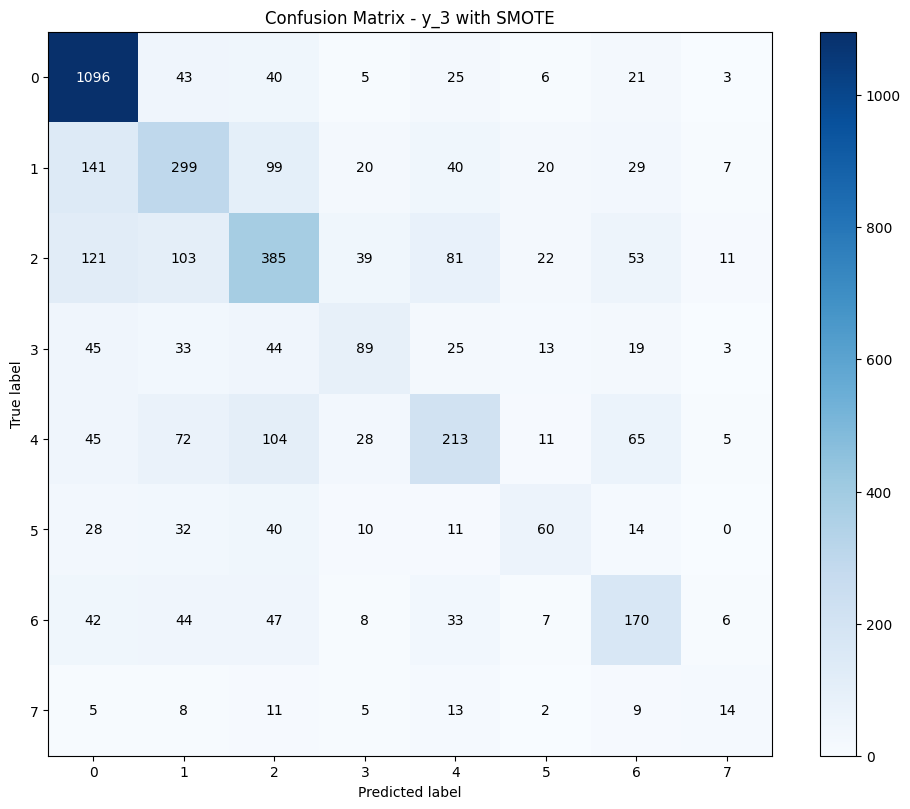

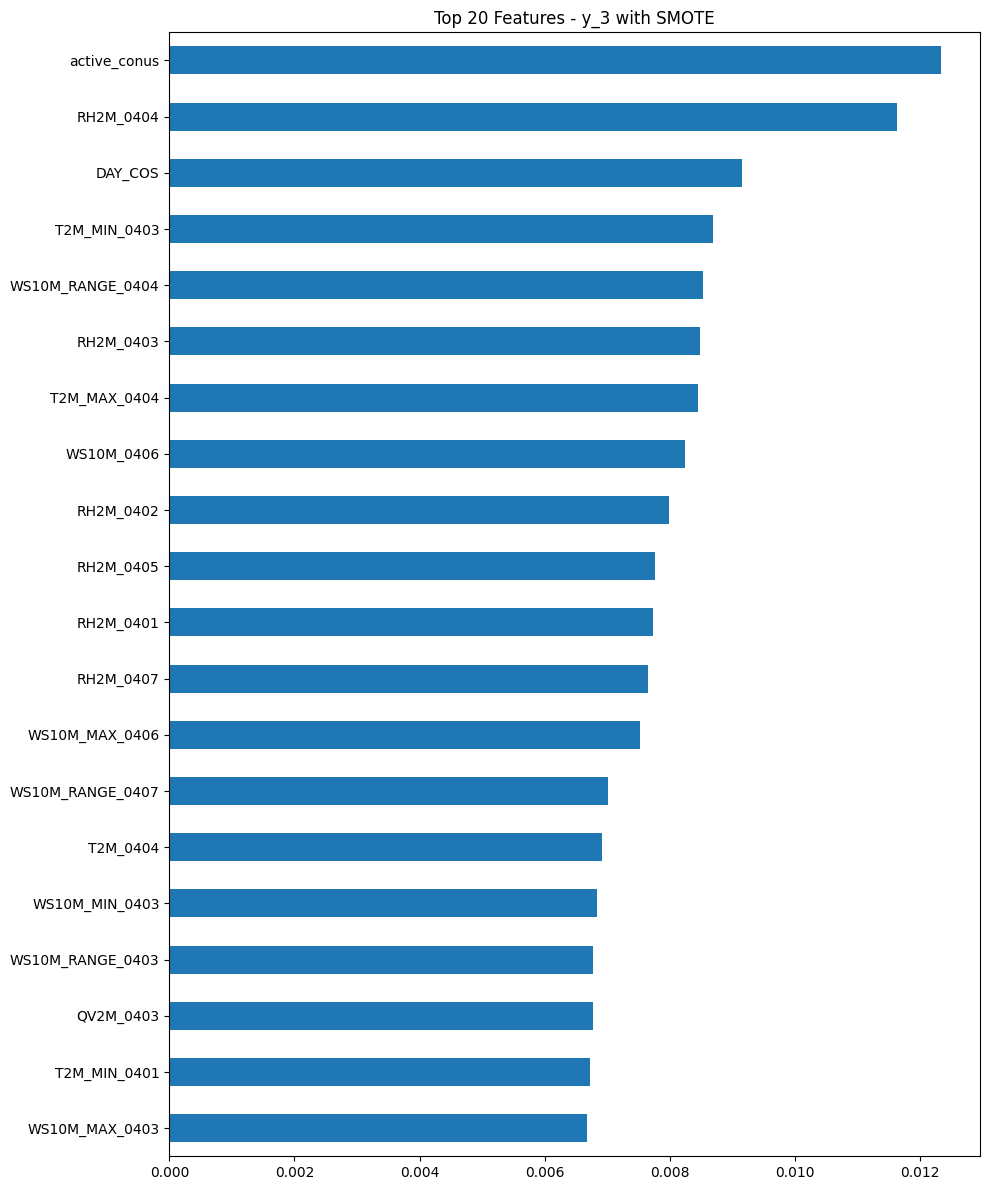


Class distribution before SMOTE for y_7:
    Class 0: 4120 samples (33.16%)
    Class 1: 2363 samples (19.02%)
    Class 2: 2403 samples (19.34%)
    Class 3: 685 samples (5.51%)
    Class 4: 1304 samples (10.49%)
    Class 5: 395 samples (3.18%)
    Class 6: 903 samples (7.27%)
    Class 7: 253 samples (2.04%)

Class distribution after SMOTE for y_7:
    Class 0: 4120 samples (12.50%)
    Class 1: 4120 samples (12.50%)
    Class 2: 4120 samples (12.50%)
    Class 3: 4120 samples (12.50%)
    Class 4: 4120 samples (12.50%)
    Class 5: 4120 samples (12.50%)
    Class 6: 4120 samples (12.50%)
    Class 7: 4120 samples (12.50%)

Validation Results with SMOTE for y_7:
Accuracy: 0.3981
Precision: 0.3228
Recall: 0.3068
F1 Score: 0.3102


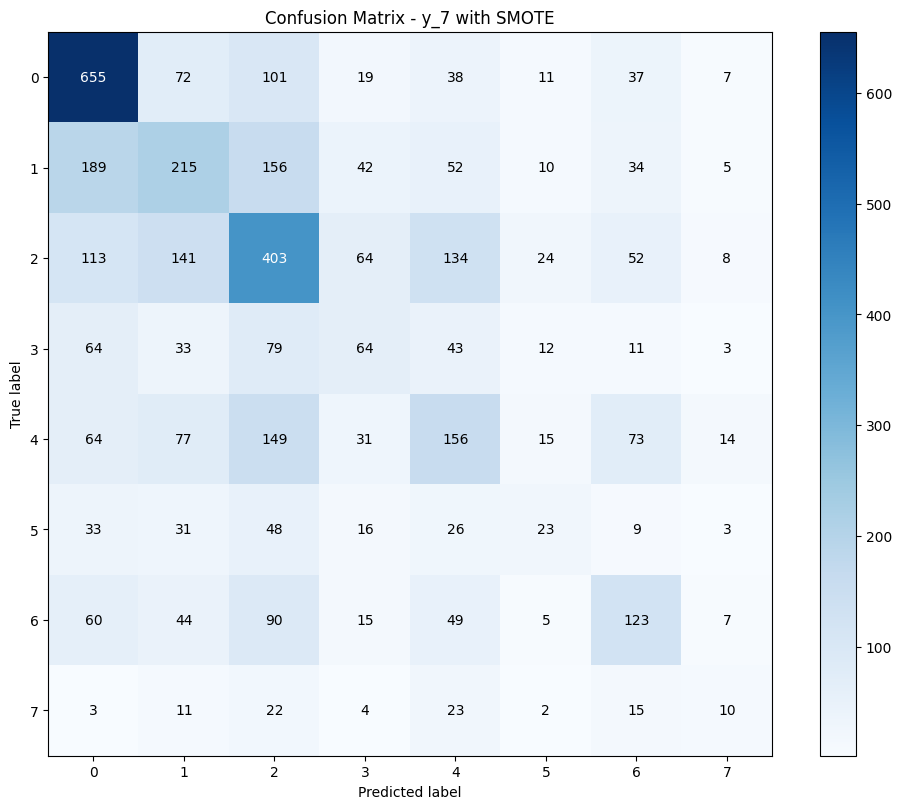

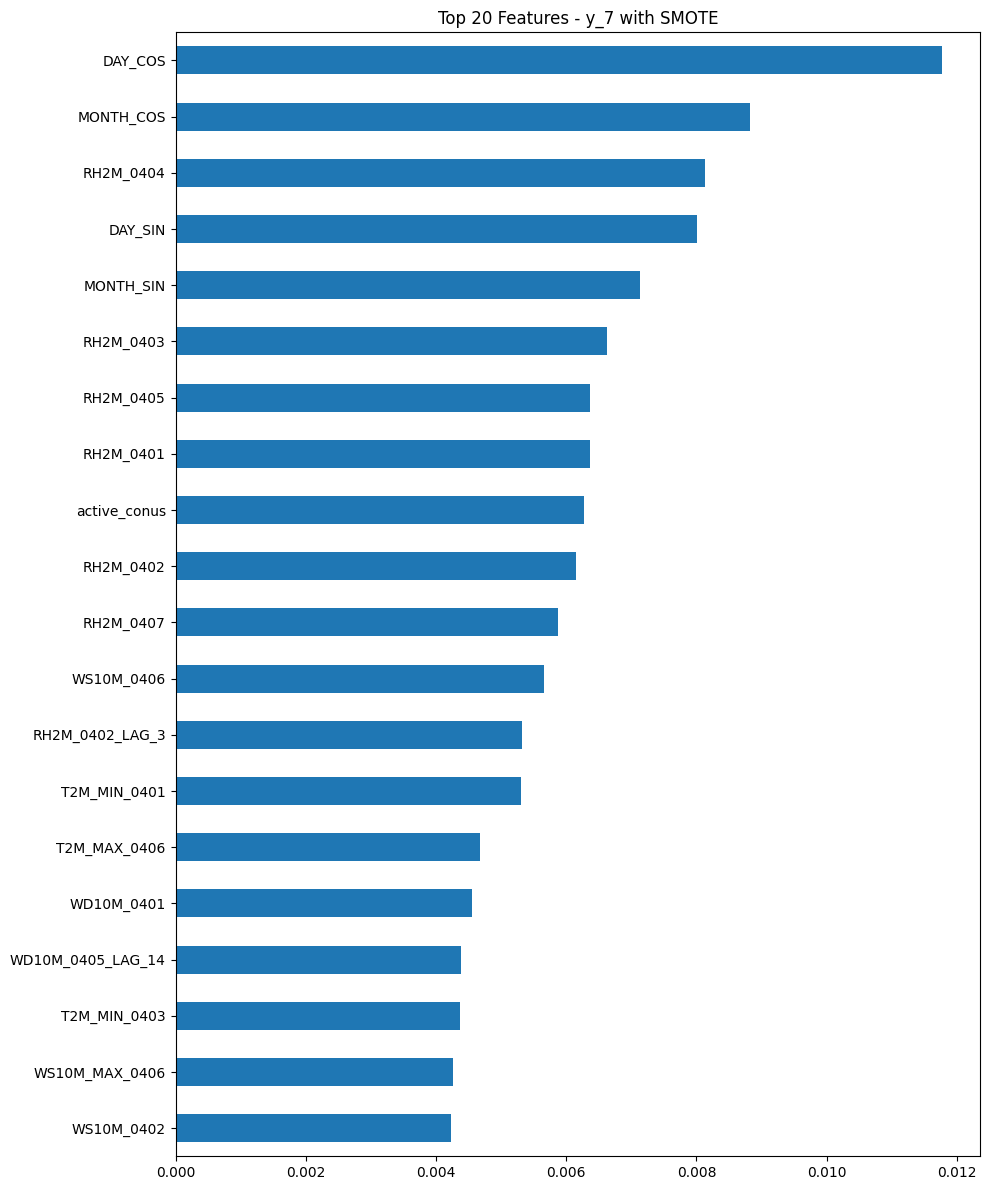


Class distribution before SMOTE for y_14:
    Class 0: 3420 samples (27.52%)
    Class 1: 2696 samples (21.70%)
    Class 2: 2446 samples (19.68%)
    Class 3: 782 samples (6.29%)
    Class 4: 1437 samples (11.56%)
    Class 5: 429 samples (3.45%)
    Class 6: 920 samples (7.40%)
    Class 7: 296 samples (2.38%)

Class distribution after SMOTE for y_14:
    Class 0: 3420 samples (12.50%)
    Class 1: 3420 samples (12.50%)
    Class 2: 3420 samples (12.50%)
    Class 3: 3420 samples (12.50%)
    Class 4: 3420 samples (12.50%)
    Class 5: 3420 samples (12.50%)
    Class 6: 3420 samples (12.50%)
    Class 7: 3420 samples (12.50%)

Validation Results with SMOTE for y_14:
Accuracy: 0.3213
Precision: 0.2433
Recall: 0.2351
F1 Score: 0.2342


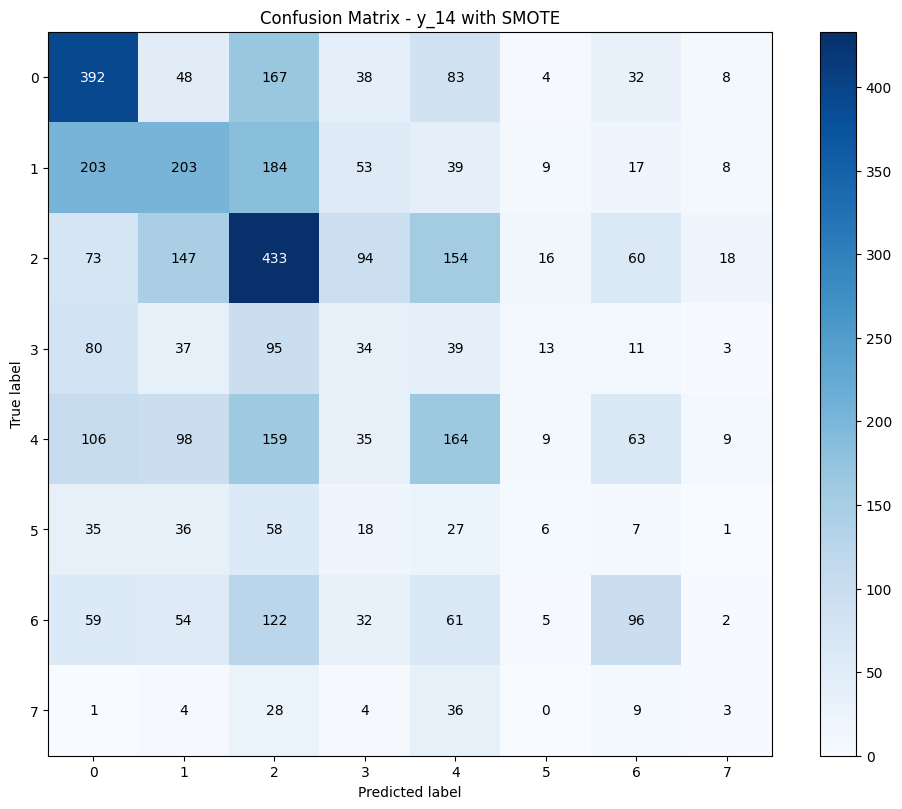

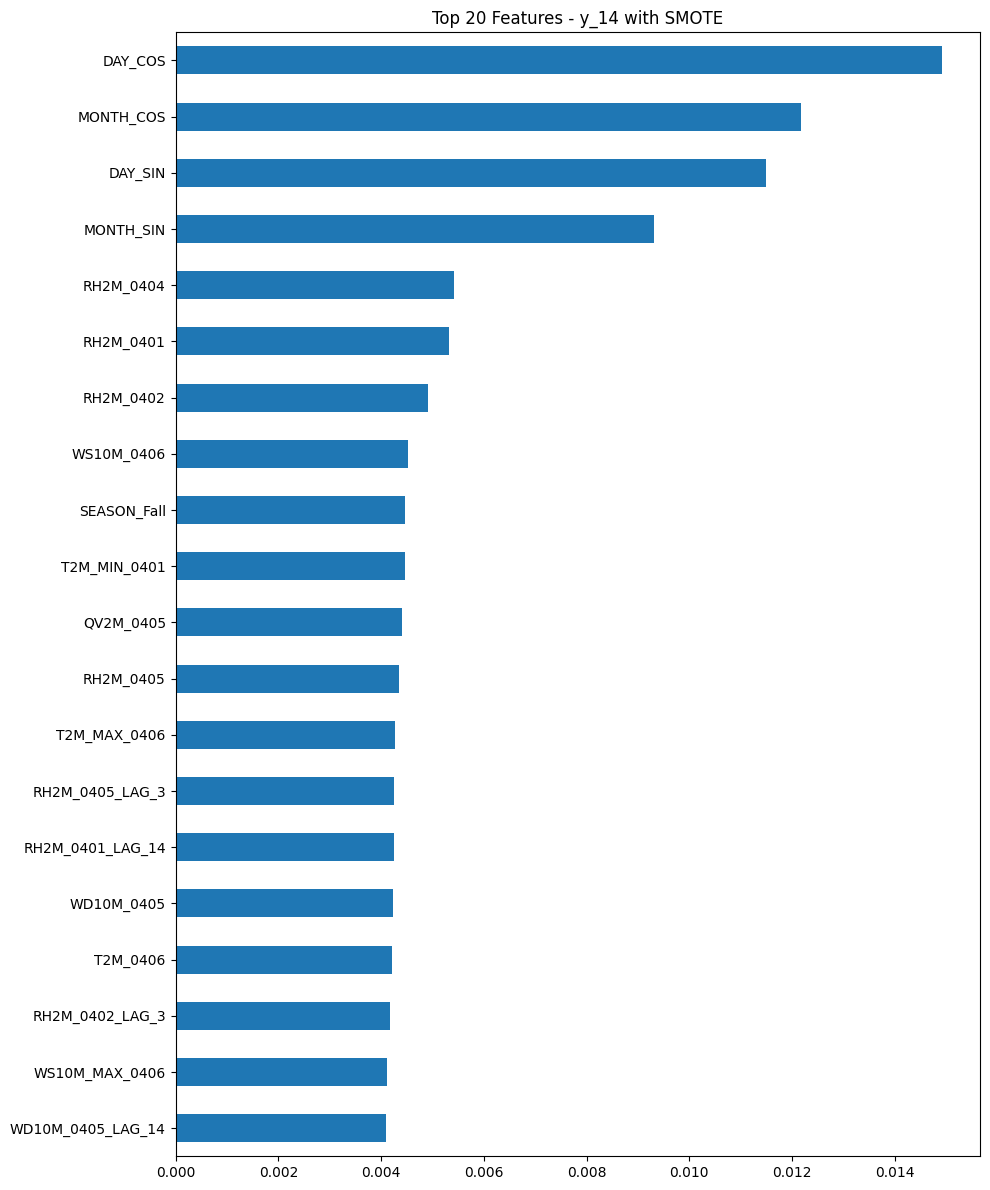

Test Results for y_3:
Accuracy: 0.5225
Precision: 0.4401
Recall: 0.4145
F1 Score: 0.4237


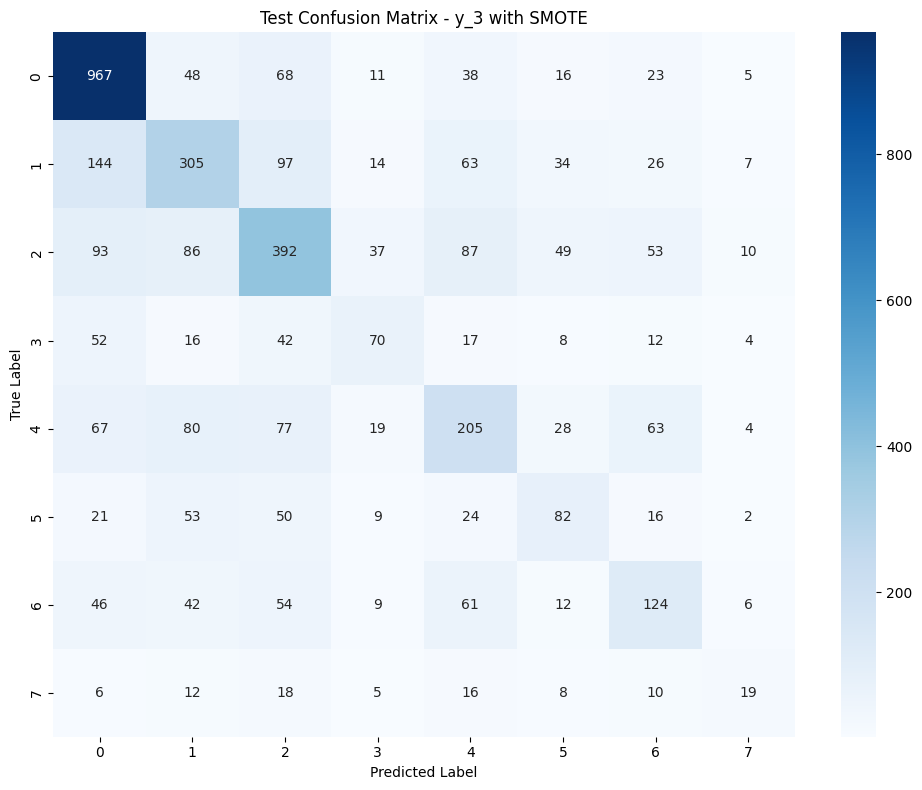

Test Results for y_7:
Accuracy: 0.3921
Precision: 0.3053
Recall: 0.2918
F1 Score: 0.2939


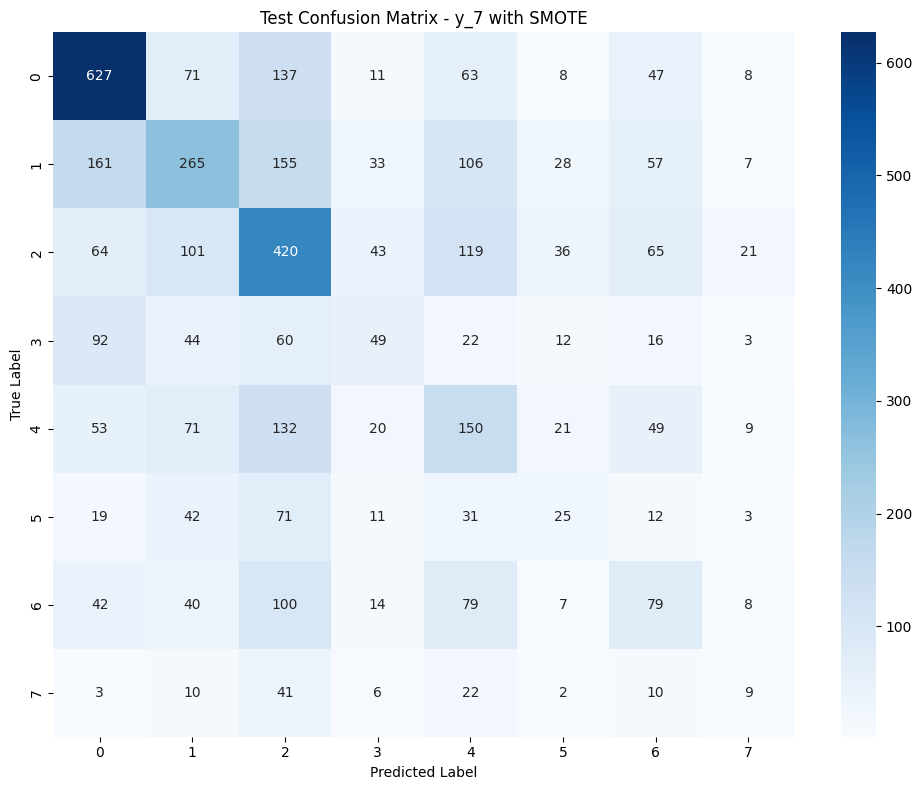

Test Results for y_14:
Accuracy: 0.3250
Precision: 0.2391
Recall: 0.2340
F1 Score: 0.2320


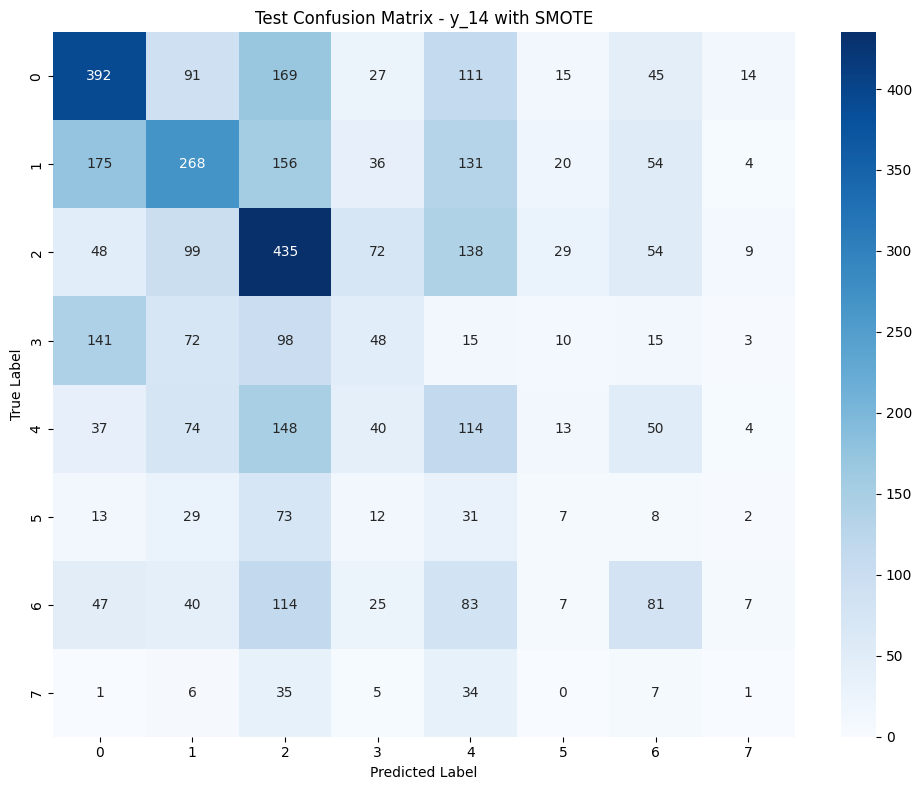

y_3        0.5225     0.4401     0.4145     0.4237    
y_7        0.3921     0.3053     0.2918     0.2939    
y_14       0.3250     0.2391     0.2340     0.2320    


In [34]:
# Apply just SMOTE without PCA
smote_results = {}
for target in ['y_3', 'y_7', 'y_14']:
    smote_results[target] = apply_smote_and_train(
        X_train_model, y_train[target], X_val_model, y_val[target], target
    )

# Evaluate SMOTE models on test set
smote_test_results = {}
for target in ['y_3', 'y_7', 'y_14']:

    # Get the trained model
    model = smote_results[target]['model']

    # Make predictions on test set
    y_test_pred = model.predict(X_test_model)

    # Calculate metrics
    accuracy = accuracy_score(y_test[target], y_test_pred)
    conf_matrix = confusion_matrix(y_test[target], y_test_pred)
    report = classification_report(y_test[target], y_test_pred, output_dict=True)

    # Extract precision, recall, and f1
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = report['macro avg']['f1-score']

    print(f"Test Results for {target}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plot confusion matrix for test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Test Confusion Matrix - {target} with SMOTE')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # Store results
    smote_test_results[target] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': report,
        'predictions': y_test_pred
    }


for target in ['y_3', 'y_7', 'y_14']:
    results = smote_test_results[target]
    print(f"{target:<10} {results['accuracy']:<10.4f} {results['precision']:<10.4f} {results['recall']:<10.4f} {results['f1']:<10.4f}")

